# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [3]:
sns.set_theme(style="whitegrid")

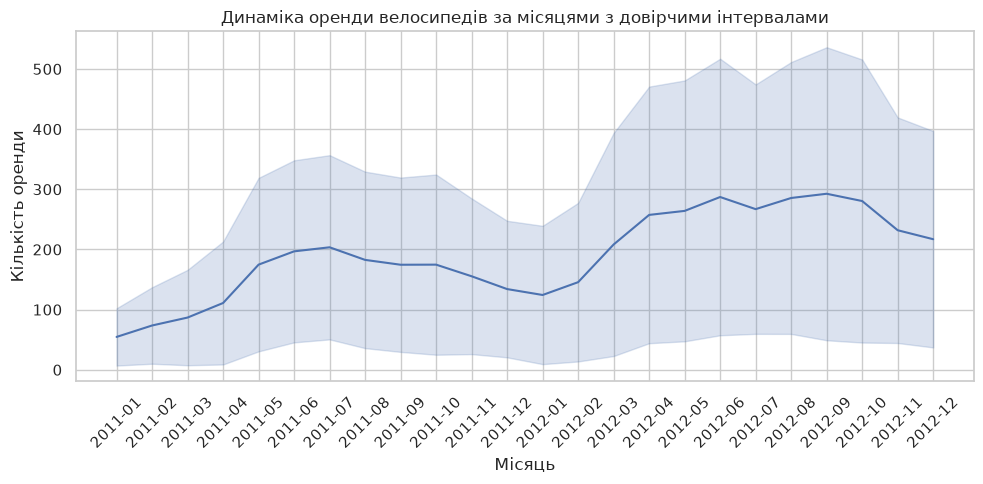

In [4]:
plt.figure(figsize=(10,5))
sns.lineplot(df, x='month_year', y='count', errorbar='sd')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)

plt.tight_layout();

Найбільша невизначенність даних спостерігається у вересні 2012 року, де довірчий інтервал найбільший


## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

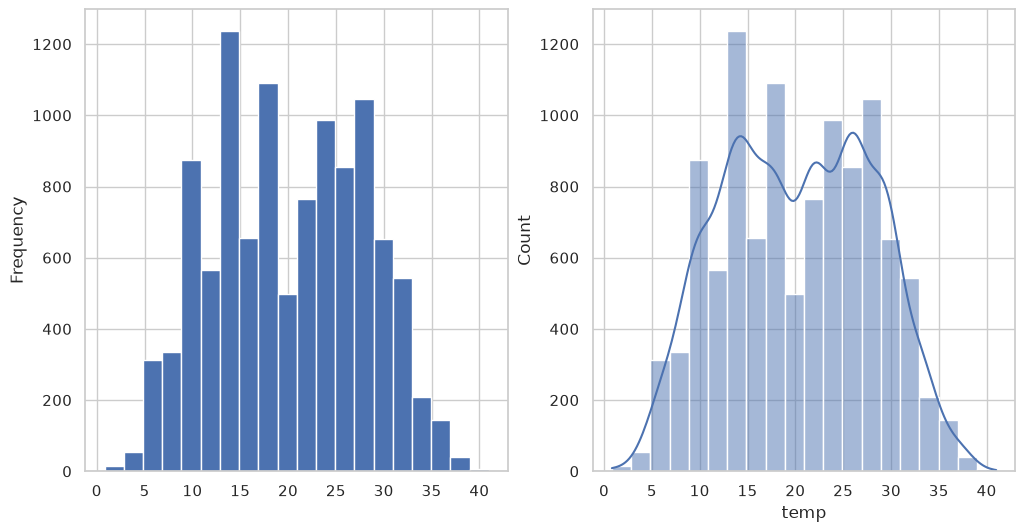

In [5]:
plt.figure(figsize=(12,6))

# hist with Pandas
plt.subplot(1,2,1)
df['temp'].plot.hist(bins=20, 
        )

# hist with Seaborn
plt.subplot(1,2,2)
sns.histplot(df['temp'], 
            bins=20,
            kde=True
        )

plt.show()

1) гістограма побудована за допомогою seaborn має менш яскраву кольорову гаму, в іншому візуально схожі.
   Також відрізняються підписи осей по замовчуванню: в гістограмі seaborn підписані обидві осі (xlabel - назва колонки з датафрейму, ylabel - count). В гістограмі pandas підписано тільки ylabel як Frequency. Підпис на осі у на гістограмі seaborn більш вірний з точки зору статистичної лексики.

2) Додаткова  лінія на графіку в Seaborn - це згладжена гістограма, яка показує наближений розподіл даних в наборі. За її допомогою краще можна оцінити форму розподілу, бо форма звичайної гісторами може відрізнятись по формі залежно від розміру бінів. 

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [6]:
# додано в датафрейм підписи видів погоди для точності співвідношення цифр і підписів на графіку
weather_map = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
df['weather_name'] = df['weather'].map(weather_map)

# переведено типи погоди в категоріальний тип
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
df['weather_name'] = pd.Categorical(df['weather_name'], categories=weather_order, ordered=True)

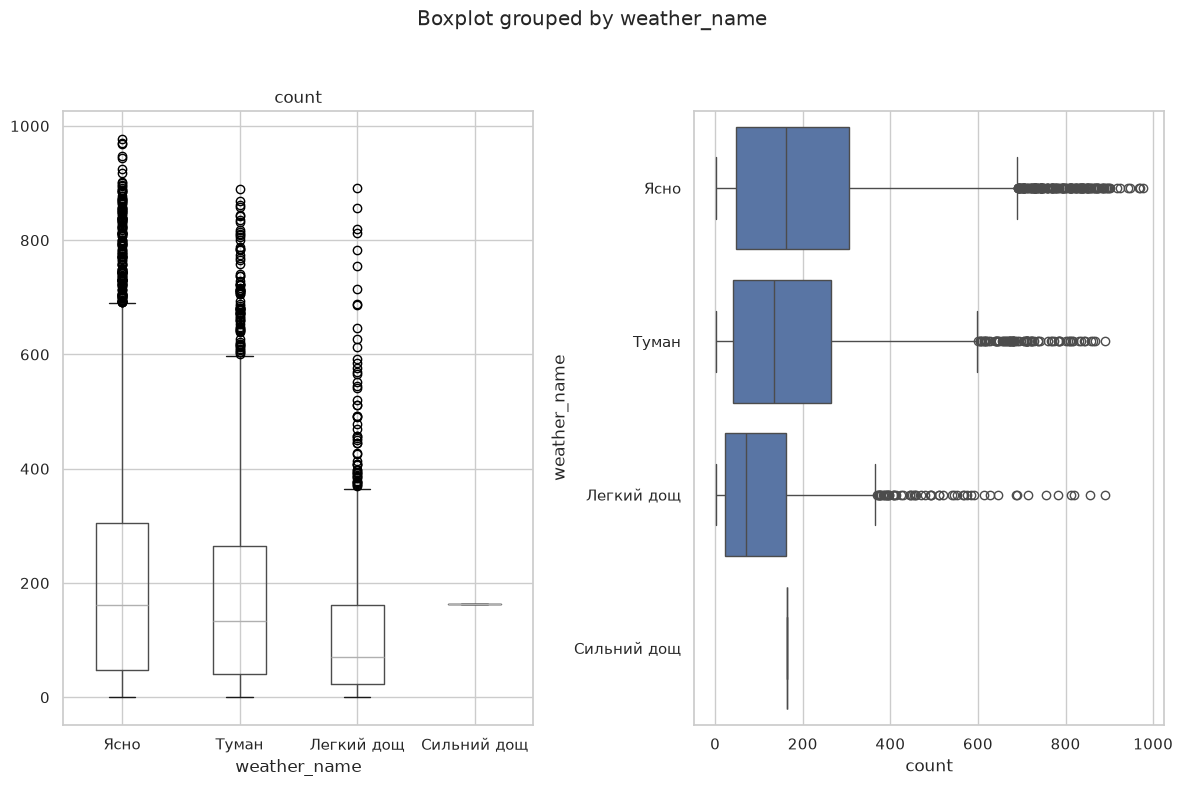

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# boxplot with Pandas
df.boxplot(
    column='count',
    by='weather_name',
    ax=axes[0]
)

# boxplot with Seaborn
sns.boxplot(df, x='count', y='weather_name', ax=axes[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Різниця в графіках:
- у pandas графік за замовченням будується вертикальний, а у seaborn - горизонтальний.
- у seaborn - коробочки зафарбовуються за замовченням, а у pandas - ні.
- графік pandas сам будує окрему фігуру і тільки за допомогою plt.subplots та параметром ax=axes[] вдалося розмістити його поряд з іншим графіком. У seaborn графіка такого ефекту немає
- графік pandas сам додає назву фігурі "Boxplot grouped by weather_name та підписує count не по осі у, а вверху. Натомість seaborn осі коректно підписує, але назву не робить


<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [8]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour', 'month_year',
       'weather_name'],
      dtype='str')

In [9]:
correlation = df[['temp',  'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()


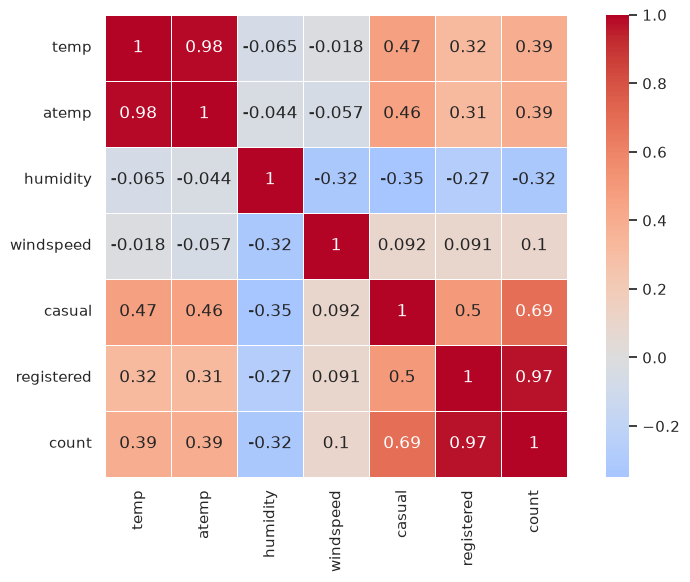

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(correlation, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5
           )

plt.show();

Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

Із загальною кількістю оренди (count) найсильніше корелюють кількість оренд registered та casual користувачів.
Це тому, що count є сумою значень registered та casual. Так як кореляція count з registered більша, то можна зробити висновок,
що сервісом оренди користується більше зареєстрованих користувачів.


Якщо це не враховувати, тоді найбільше корелюють з температурою (temp, atemp)
Що логічно, бо чим тепліше, тим більше оренд, але до певної міри, бо коли спека, кількість оренд спадає.


Яка кореляція між temp та atemp? Чому?

Між temp та atemp кореляція становить 0.98, бо це майже однакові показники: temp - фактична температура, а atemp - температура, по відчуттю, що може відрізнятись від temp на 2-3 градуси із-за інших погодних факторів (вологість, швидкість вітру)

Які змінні мають негативну кореляцію?

Негативну кореляцію має humidity зі всіма іншими змінними (крім, самої себе), а також windspeed, крім humidity, має близьку до 0 негативну кореляцію з temp та atemp.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [11]:
df['quarter_year'] = df.index.to_period('Q')
df['quarter_year']  = df.quarter_year.astype(str)
df['quarter_year'] 

datetime
2011-01-01 00:00:00    2011Q1
2011-01-01 01:00:00    2011Q1
2011-01-01 02:00:00    2011Q1
2011-01-01 03:00:00    2011Q1
2011-01-01 04:00:00    2011Q1
                        ...  
2012-12-19 19:00:00    2012Q4
2012-12-19 20:00:00    2012Q4
2012-12-19 21:00:00    2012Q4
2012-12-19 22:00:00    2012Q4
2012-12-19 23:00:00    2012Q4
Name: quarter_year, Length: 10886, dtype: str

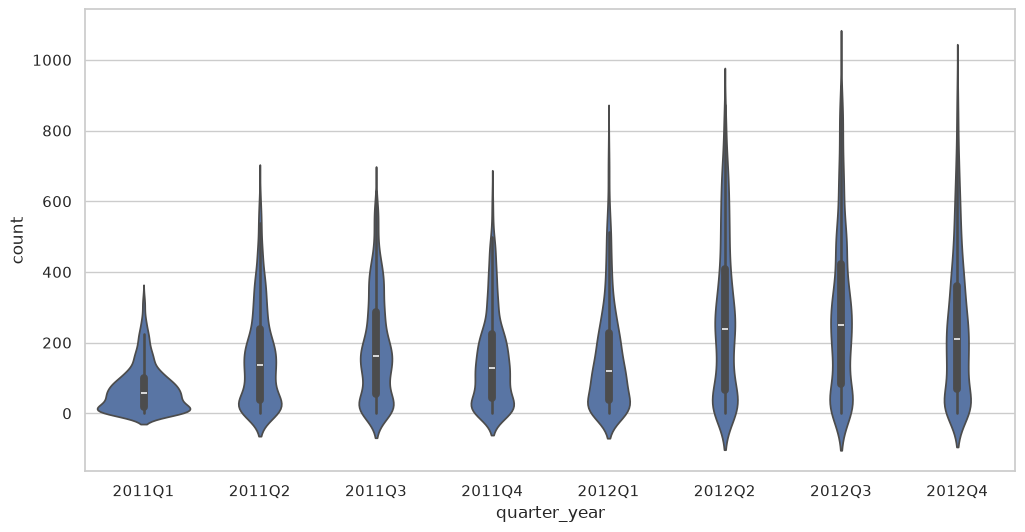

In [12]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, 
               x='quarter_year', 
               y='count'
            );

Що показує "товщина" violin plot?

"Товщина" violin plot показує щільність розподілу даних так, що зліва і справа є дзеркальне відображення kde розподілу, якщо не заданий розподіл по категоріям (split). Чим "товстіша" violin plot, тим щільніші дані.

В якому кварталі найбільша варіабельність оренди?

Найбільша варіабельність оренди у 3му кварталі 2012 року: значення кількості оренди досягає 1000 оренд, про що свідчить довжина violin plot.

Яка перевага violin plot над звичайним box plot?

Головна перевана violin plot над звичайним box plot в тому, що додатково показується розподіл даних і виглядає компактно і елегантно.
Звичайний box plot обмежується статистичними показниками (медіана, викиди, квартилі). 
Крім того, на violin plot можна розділити розподіл даних на 2 категорії зліва і справа (наприклад, чоловіки та жінки)


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [13]:
sample_df = df[['season','temp','humidity', 'windspeed', 'count']]


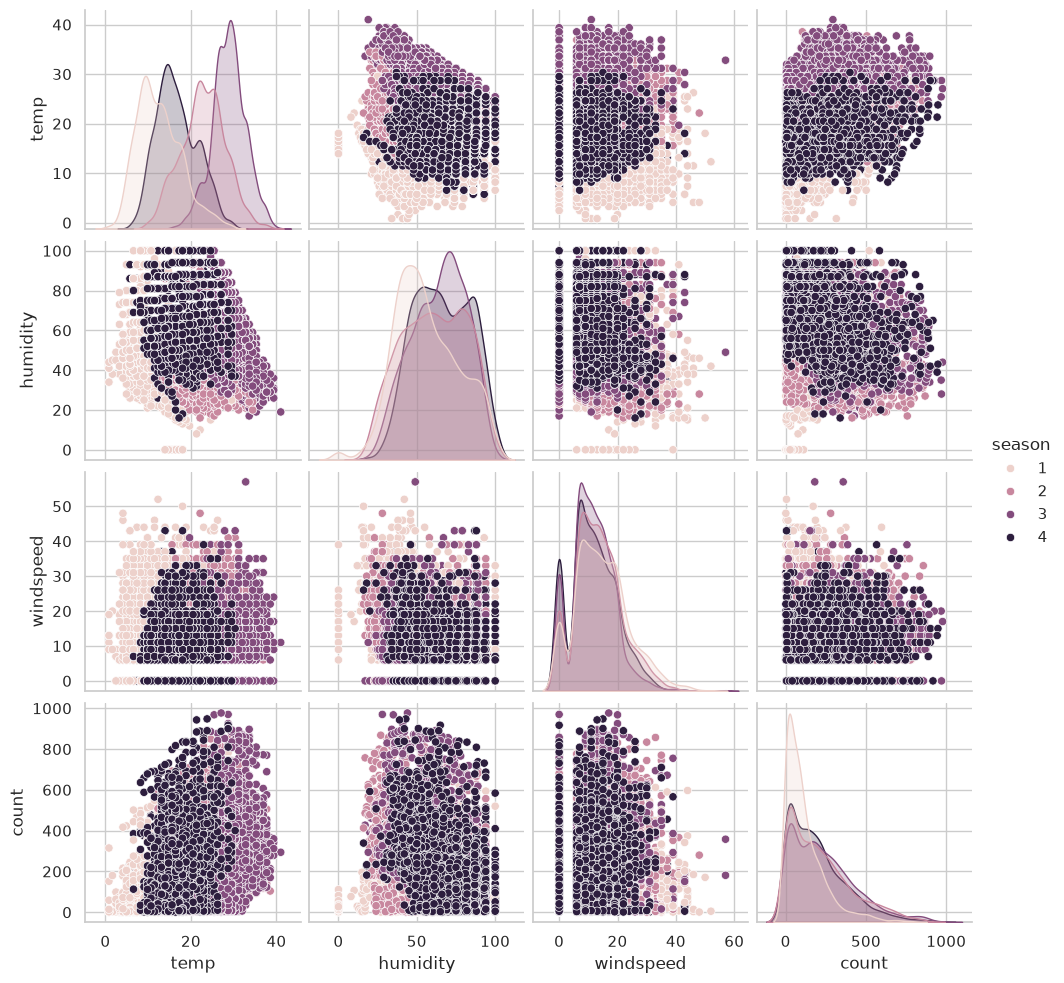

In [14]:
sns.pairplot(sample_df, hue="season")

plt.show();

Між якими змінними спостерігається найсильніший лінійний зв'язок?
 
Найсильніший лінійний зв'язок спостерігається між змінними temp і count:
зі зростанням температури кількість оренд загалом зростає, особливо в діапазоні 10-30°C
хоча він не строго лінійний, а скоріше помірно сильний, але він найвиразніший серед усіх пар.
бо наприклад, humidity і count має зворотний тренд (вища вологість - менше оренд), але розкид точок більший, зв'язок слабший.

Яка характеристика найбільше відрізняється між кварталами?

Найбільше між кварталами відрізняється характеристика temp: це помітно на графіку зліва вверху, де фігури розподілу мало накладаються одна на одну. 
Інші характеристики мало відрізняються.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

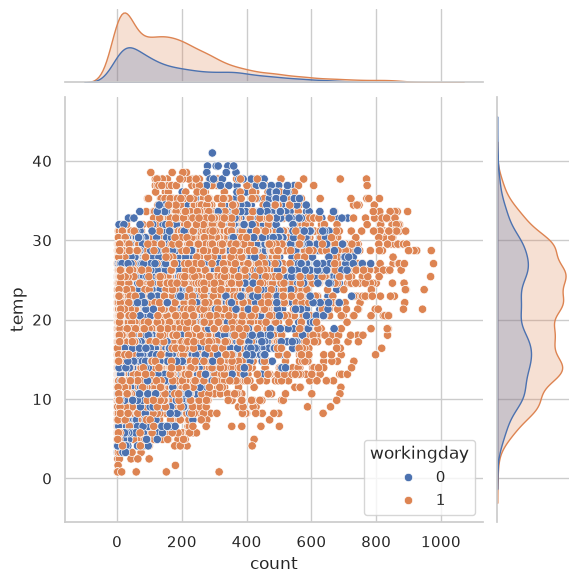

In [15]:
sns.jointplot(data=df, x="count", y="temp", hue="workingday");

Що показують графіки по краях?

Графіки по краям показують розподіл даних: з верхнього края - розподіл кількості оренд по категоріям робочий день чи вихідний, згідно з легендою; а справа - розподіл температур, також розфарбований згідно легенди.

Чи є різниця у поведінці користувачів у робочий і неробочий день?

Так є. Графік розподілу оренд має помітну скошеність вправо і значно довший "хвіст" праворуч, що свідчить про більш активне користування орендою у робочі дні.
На scatter plot видно, що помаранчеві точки густіше заповнюють область count > 600, а синіх майже немає. Це також свідчить про те, що в робочі дні користувачі використовують сервіс частіше.
